# Práctica 04: Análisis exploratorio de DonorsChoose

Una guía visual y narrativa para comprender la distribución de donantes, proyectos y patrones geográficos en DonorsChoose.

**Programa de estudios:** Ingeniería en Desarrollo y Gestión de Software  
**Asignatura:** Extracción de Conocimiento en Bases de Datos  
**Docente:** M.T.I. Marco A. Ramírez Hernández  
**Periodo:** Mayo - Agosto 2026

**Nombre del estudiante:** Derek Sesni Carreño  
**Matrícula:** 230892  
**Grado y grupo:** 9A° IDGS

# Unidad 2: Preparación de los datos

**Contexto:** DonorsChoose.org es una organización sin fines de lucro con sede en Estados Unidos que permite a personas y escuelas solicitar financiamiento para proyectos educativos. Fundada en 2000 por Charles Best, ha consolidado su papel como una de las plataformas de financiamiento colectivo más reconocidas en el ámbito educativo. A lo largo del tiempo, ha apoyado miles de proyectos, especialmente en escuelas públicas y comunidades con recursos limitados.

Este análisis explora cómo se distribuyen los donantes, los proyectos y los patrones geográficos dentro de la plataforma.

# Contenido

1. [Cargar datos](#cargar-datos)
2. [Explorar a los donantes](#explorando-a-los-donantes)
   1. [Vista general de los donantes](#vista-general-de-los-donantes)
   2. [Estados con mayor proporción de donantes por habitante](#estados-con-mayor-proporcion-de-donantes-por-habitante)
   3. [Visualización de la ubicación de los donantes](#visualizacion-de-la-ubicacion-de-los-donantes)
      - [Donantes de California](#donantes-de-california)
      - [Donantes de Florida](#donantes-de-florida)
      - [Donantes de Nueva York](#donantes-de-nueva-york)
   4. [Visualización de todos los donantes](#visualizacion-de-todos-los-donantes)
   5. [Número de donantes docentes y no docentes de cada estado](#numero-de-donantes-docentes-y-no-docentes-por-estado)
3. [Exploración de donaciones](#exploracion-de-donaciones)
   1. [Proyectos destacados](#proyectos-destacados)
   2. [Principales donantes](#principales-donantes)
   3. [Análisis de fechas de donación](#analisis-de-fechas-de-donacion)

<a id="cargar-datos"></a>
## 1. Cargar datos

Carguemos las bibliotecas necesarias e importemos el conjunto de datos a la memoria con Pandas. El dataset está compuesto por seis archivos: donantes, donaciones, profesores, escuelas, recursos y proyectos.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("Librerías cargadas exitosamente") 

import os

# Ruta base
base_path = r'c:\Users\derek\Desktop\ECBD_9A_IDGS_PRACTICAS_230892\Practica04'

# Cargar datasets
projects = pd.read_csv(os.path.join(base_path, 'Projects.csv'))
donations_df = pd.read_csv(os.path.join(base_path, 'Donations.csv'))
donors_df = pd.read_csv(os.path.join(base_path, 'Donors.csv'))
teachers_df = pd.read_csv(os.path.join(base_path, 'Teachers.csv'))
schools_df = pd.read_csv(os.path.join(base_path, 'Schools.csv'))
resources_df = pd.read_csv(os.path.join(base_path, 'Resources.csv'))

print("Datasets cargados:\n")
print(f"Projects: {projects.shape}")
print(f"Donations: {donations_df.shape}")
print(f"Donors: {donors_df.shape}")
print(f"Teachers_df: {teachers_df.shape}")
print(f"Schools: {schools_df.shape}")
print(f"Resources: {resources_df.shape}")

Librerías cargadas exitosamente
Datasets cargados:

Projects: (150, 15)
Donations: (200, 7)
Donors: (200, 5)
Teachers_df: (200, 3)
Schools: (200, 9)
Resources: (250, 5)


<a id="explorando-a-los-donantes"></a>
## 2. Explorar a los donantes

In [16]:
donors_df.head(5)

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,bdd640fb06671ad11c80317fa3b1799d,San Francisco,California,Yes,114
1,8b9d2434e465e150bd9c66b3ad3c2d6d,San Jose,California,Yes,105
2,9a1de644815ef6d13b8faa1837f8a88b,San Francisco,California,No,728
3,72ff5d2a386ecbe06b65a6a48b8148f6,Houston,Texas,No,173
4,47229389571aa8766c307511b2b9437a,San Diego,California,Yes,399


<a id="vista-general-de-los-donantes"></a>
### 2.1 Vista general de los donantes

In [20]:
pip install folium branca jinja2 requests numpy


   ---------------------------------------- 0/2 [branca]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]

Note: you may need to restart the kernel to use updated packages.


In [23]:
import folium
from folium import plugins
from io import StringIO
import folium 


statesll=StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490""")

tempdf = states_df = donors_df['Donor State'].value_counts()
t1 = pd.DataFrame()
t1['Donor State'] = tempdf.index
t1['Donor Count'] = tempdf.values

# tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'sum'}).reset_index()
# t1 = tempdf.sort_values('Donation Amount', ascending=False)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(t1, on='Donor State', how='inner')
sdf 

map4 = folium.Map(location=[39.50, -98.35], tiles='CartoDB dark_matter', zoom_start=3.5)
for j, rown in sdf.iterrows():
    rown = list(rown)
    folium.CircleMarker([float(rown[1]), float(rown[2])], popup="<b>State:</b>" + rown[0].title() +"<br> <b>Donors:</b> "+str(int(rown[3])), radius=float(rown[3])*0.0001, color='#be0eef', fill=True).add_to(map4)
map4

In [25]:
from plotly.offline import iplot, init_notebook_mode
from plotly.subplots import make_subplots

import plotly.graph_objects as go

init_notebook_mode(connected=True)

# Crear los trazos para los subplots
def bar_hor(df, col, title, color, width, height, font_size, limit=10, return_trace=False, rev=False):
    counts = df[col].value_counts()
    if rev:
        counts = counts.sort_values(ascending=True).head(limit)
    else:
        counts = counts.sort_values(ascending=False).head(limit)
    y = counts.index[::-1]
    x = counts.values[::-1]
    trace = go.Bar(
        y=y,
        x=x,
        orientation='h',
        marker=dict(color=color),
        name=title,
        hoverinfo='x+y'
    )
    if return_trace:
        return trace
    fig = go.Figure(trace)
    fig.update_layout(title=title, width=width, height=height, font=dict(size=font_size))
    return fig

trace2 = bar_hor(
    donors_df, 'Donor State',
    "Top States with maximum Donors", '#c2d2ed',
    600, 400, 200, limit=10, return_trace=True
)

trace4 = bar_hor(
    donors_df, 'Donor State',
    "Top States with minimum Donors", '#c2d2ed',
    600, 400, 200, limit=10, return_trace=True, rev=True
)

city_counts = donors_df['Donor City'].value_counts().head(10)
trace1 = go.Bar(
    y=city_counts.index[::-1],
    x=city_counts.values[::-1],
    orientation='h',
    marker=dict(color='#4fe4f9')
)

# Crear figura con subplots
fig = make_subplots(
    rows=2,
    cols=2,
    specs=[[{}, {}], [{'colspan': 2}, None]],
    print_grid=False,
    subplot_titles=[
        'States with maximum Donors',
        'States with minimum Donors',
        'Cities with maximum Donors'
    ]
)

fig.add_trace(trace2, row=1, col=1)
fig.add_trace(trace4, row=1, col=2)
fig.add_trace(trace1, row=2, col=1)

fig.update_layout(height=800, showlegend=False)
iplot(fig)
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace4, 1, 2);
fig.append_trace(trace1, 2, 1);
# fig.append_trace(trace4, 2, 2);

fig['layout'].update(height=800, showlegend=False);
iplot(fig); 

### Conclusión

California, con casi 300 000 donantes, es el estado con mayor número de donantes. San Francisco y Los Ángeles son las principales ciudades donantes. California también es el estado con mayor número de proyectos y escuelas.

Nueva York, Texas y Florida son otros de los estados con mayor número de donantes, con aproximadamente 137 000, 134 000 y 108 000 donantes, respectivamente. Sus principales ciudades son Nueva York, Miami, Tampa, Houston y Dallas.

Dakota del Norte, Dakota del Sur, Vermont y Wyoming son los estados con menor número de donantes. En los datos de los estados aparece la categoría "otros", que probablemente indica donantes de otros países.

Entre las ciudades, las tres principales son: Chicago (35 000 donantes), Nueva York (27 000 donantes) y Brooklyn (22 000 donantes), que cuenta con el mayor número de donantes. Las siguientes dos ciudades son California (estado con el mayor número de donantes): Los Ángeles y San Francisco, con aproximadamente 18.000 y 16.000 donantes respectivamente.

<a id="estados-con-mayor-proporcion-de-donantes-por-habitante"></a>
### 2.3 Estados con mayor proporción de donantes por habitante

In [26]:
census_2013 = {'Mississippi': 2991207, 'Iowa': 3090416, 'Oklahoma': 3850568, 'Delaware': 925749, 'Minnesota': 5420380, 'Alaska': 735132, 'Illinois': 12882135, 'Arkansas': 2959373, 'New Mexico': 2085287, 'Indiana': 6570902, 'Maryland': 5928814, 'Louisiana': 4625470, 'Texas': 26448193, 'Wyoming': 582658, 'Arizona': 6626624, 'Wisconsin': 5742713, 'Michigan': 9895622, 'Kansas': 2893957, 'Utah': 2900872, 'Virginia': 8260405, 'Oregon': 3930065, 'Connecticut': 3596080, 'New York': 19651127, 'California': 38332521, 'Massachusetts': 6692824, 'West Virginia': 1854304, 'South Carolina': 4774839, 'New Hampshire': 1323459, 'Vermont': 626630, 'Georgia': 9992167, 'North Dakota': 723393, 'Pennsylvania': 12773801, 'Florida': 19552860, 'Hawaii': 1404054, 'Kentucky': 4395295, 'Rhode Island': 1051511, 'Nebraska': 1868516, 'Missouri': 6044171, 'Ohio': 11570808, 'Alabama': 4833722, 'South Dakota': 844877, 'Colorado': 5268367, 'Idaho': 1612136, 'New Jersey': 8899339, 'Washington': 6971406, 'North Carolina': 9848060, 'Tennessee': 6495978, 'Montana': 1015165, 'District of Columbia': 646449, 'Nevada': 2790136, 'Maine': 1328302}

donors_from_states = dict(donors_df['Donor State'].value_counts())

don_pop = {}
for state, don in donors_from_states.items():
    if state not in census_2013:
        continue
    don_pop[state]  = float(don)*100000/ census_2013[state]

import operator
don_pop = sorted(don_pop.items(), key=operator.itemgetter(1), reverse = True)
xx = [x[0] for x in (don_pop)][1:]
yy = [x[1] for x in (don_pop)][1:]

trace2 = go.Bar(
    x=xx,
    y=yy,
    name='Donors to Population',
    marker=dict(color='green'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'States with highest Donors to Population Ratio',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

Se genera un gráfico interesante, ya que los estados de Carolina del Sur (con una población de 4.774.839 habitantes), Massachusetts (con una población de 6.692.824 habitantes) y Connecticut (con una población de 3.596.080 habitantes) presentan la mayor proporción de donantes por habitante y el mayor número de donantes por cada 100.000 habitantes. Carolina del Sur registra 985 donantes por cada 100.000 habitantes, Massachusetts 907 donantes por cada 100.000 habitantes y Connecticut 878 donantes por cada 100.000 habitantes.

Wyoming, Nebraska y Nuevo México tienen el menor número de donantes por cada 100.000 habitantes, con 285, 335 y 363 donantes, respectivamente.

Texas, uno de los estados con mayor número de donantes, presenta una proporción menor de donantes por habitante, con 508 donantes por cada 100.000 habitantes.

<a id="visualizacion-de-la-ubicacion-de-los-donantes"></a>
### 2.4 Visualización de la ubicación de los donantes

#### 2.4.1 Donantes ubicados en California

In [27]:
calcit = StringIO(u"""Name,Latitude,Longitude,Total Donors,Color,Size
Los Angeles,34.052233,-118.243686,"17,922.000000",#0061ff,10
San Francisco,37.774931,-122.419417,"16,553.000000",#0061ff,10
San Diego,32.715328,-117.157256,"9,072.000000",#0061ff,10
San Jose,37.339386,-121.894956,"7,674.000000",#0061ff,10
Oakland,37.804364,-122.271114,"6,783.000000",#0061ff,10
Sacramento,38.581572,-121.494400,"4,701.000000",#0061ff,10
Bakersfield,35.373292,-119.018711,"3,758.000000",#0061ff,10
Long Beach,33.768322,-118.195617,"3,120.000000",#0061ff,10
Berkeley,37.871592,-122.272747,"2,898.000000",#0061ff,10
Irvine,33.683947,-117.794694,"2,765.000000",#0061ff,10
Fremont,37.548269,-121.988572,"2,716.000000",#0061ff,10
Walnut Creek,37.910078,-122.065183,"2,255.000000",#0061ff,10
Huntington Beach,33.660297,-117.999225,"2,185.000000",#0061ff,10
Murrieta,33.553914,-117.213922,"1,982.000000",#0061ff,10
Pleasanton,37.662431,-121.874678,"1,970.000000",#0061ff,10
Torrance,33.83585,-118.340628,"1,957.000000",#0061ff,10
San Mateo,37.562992,-122.325525,"1,956.000000",#0061ff,10
Santa Monica,34.019453,-118.491192,"1,780.000000",#0061ff,10
Livermore,37.681875,-121.768008,"1,776.000000",#0061ff,10
Santa Rosa,38.440467,-122.714431,"1,752.000000",#0061ff,10
Concord,37.977978,-122.031072,"1,623.000000",#0061ff,10
Alameda,37.765206,-122.241636,"1,548.000000",#0061ff,10
Fresno,36.746842,-119.772586,"1,543.000000",#0061ff,10
San Ramon,37.779928,-121.978014,"1,533.000000",#0061ff,10
Anaheim,33.835292,-117.914503,"1,475.000000",#0061ff,10
Pasadena,34.147786,-118.144517,"1,429.000000",#0061ff,10
Glendale,34.142508,-118.255075,"1,427.000000",#0061ff,10
Riverside,33.95335,-117.396156,"1,425.000000",#0061ff,10
Sunnyvale,37.368831,-122.036350,"1,406.000000",#0061ff,10
Chula Vista,32.640053,-117.084197,"1,398.000000",#0061ff,10
Mountain View,37.386053,-122.083850,"1,398.000000",#0061ff,10
Elk Grove,38.4088,-121.371617,"1,397.000000",#0061ff,10
Santa Clarita,34.391664,-118.542586,"1,382.000000",#0061ff,10
Burbank,34.180839,-118.308967,"1,357.000000",#0061ff,10
Redwood City,37.485214,-122.236356,"1,323.000000",#0061ff,10
Chico,39.728494,-121.837478,"1,322.000000",#0061ff,10
Whittier,33.979178,-118.032844,"1,280.000000",#0061ff,10
Corona,33.875294,-117.566439,"1,239.000000",#0061ff,10
Santa Clara,37.354108,-121.955236,"1,233.000000",#0061ff,10
Orange,33.787794,-117.853111,"1,229.000000",#0061ff,10
Palo Alto,37.441883,-122.143019,"1,219.000000",#0061ff,10
Hayward,37.668819,-122.080797,"1,162.000000",#0061ff,10
Oceanside,33.195869,-117.379483,"1,157.000000",#0061ff,10
Fullerton,33.870292,-117.925339,"1,151.000000",#0061ff,10
San Rafael,37.973536,-122.531086,"1,136.000000",#0061ff,10
Folsom,38.677958,-121.176058,"1,125.000000",#0061ff,10
Simi Valley,34.269447,-118.781483,"1,069.000000",#0061ff,10
Escondido,33.119208,-117.086422,"1,062.000000",#0061ff,10
Santa Ana,33.745572,-117.867833,"1,054.000000",#0061ff,10
Redondo Beach,33.849183,-118.388408,"1,048.000000",#34ef6c,8
Stockton,37.957703,-121.290781,"1,041.000000",#34ef6c,8
Santa Cruz,36.974117,-122.030797,"1,029.000000",#34ef6c,8
Culver City,34.021122,-118.396467,"1,019.000000",#34ef6c,8
Salinas,36.677736,-121.655500,"1,017.000000",#34ef6c,8
Martinez,38.019367,-122.134133,975.000000,#34ef6c,8
Santa Barbara,34.420831,-119.698189,936.000000,#34ef6c,8
San Leandro,37.724931,-122.156078,929.000000,#34ef6c,8
Ventura,34.274639,-119.229006,922.000000,#34ef6c,8
Roseville,38.752122,-121.288006,888.000000,#34ef6c,8
Yorba Linda,33.888625,-117.813111,888.000000,#34ef6c,8
Costa Mesa,33.641133,-117.918669,887.000000,#34ef6c,8
San Marcos,33.143372,-117.166144,866.000000,#34ef6c,8
Brentwood,34.057361,-118.480511,853.000000,#34ef6c,8
South San Francisco,37.654656,-122.407750,841.000000,#34ef6c,8
Modesto,37.639097,-120.996878,837.000000,#34ef6c,8
Temecula,33.493639,-117.148364,837.000000,#34ef6c,8
Novato,38.107419,-122.569703,831.000000,#34ef6c,8
Carlsbad,33.158092,-117.350594,822.000000,#34ef6c,8
Mission Viejo,33.600022,-117.671994,817.000000,#34ef6c,8
Brea,33.916681,-117.900061,802.000000,#34ef6c,8
Garden Grove,33.773906,-117.941447,792.000000,#34ef6c,8
Dublin,37.702153,-121.935792,784.000000,#34ef6c,8
El Cajon,32.794772,-116.962528,783.000000,#34ef6c,8
Menlo Park,37.453828,-122.182186,768.000000,#34ef6c,8
Fairfield,38.249358,-122.039967,751.000000,#34ef6c,8
Pleasant Hill,37.947978,-122.060797,725.000000,#34ef6c,8
Napa,38.297539,-122.286864,711.000000,#34ef6c,8
Richmond,37.935758,-122.347750,707.000000,#34ef6c,8
Los Altos,33.796331,-118.118119,703.000000,#34ef6c,8
Daly City,37.687925,-122.470208,702.000000,#34ef6c,8
West Covina,34.068622,-117.938953,688.000000,#34ef6c,8
Lafayette,37.885758,-122.118019,660.000000,#34ef6c,8
La Mesa,32.767828,-117.023083,649.000000,#34ef6c,8
Milpitas,37.428272,-121.906625,649.000000,#34ef6c,8
Carson,33.831406,-118.282017,647.000000,#34ef6c,8
Camarillo,34.216394,-119.037603,643.000000,#34ef6c,8
Petaluma,38.232417,-122.636653,629.000000,#34ef6c,8
Newport Beach,33.618911,-117.928947,626.000000,#34ef6c,8
Pacifica,37.613825,-122.486919,619.000000,#34ef6c,8
Gilroy,37.005783,-121.568275,618.000000,#34ef6c,8
Encinitas,33.036986,-117.291983,607.000000,#34ef6c,8
El Segundo,33.919181,-118.416464,595.000000,#34ef6c,8
Downey,33.940014,-118.132569,592.000000,#34ef6c,8
Rancho Palos Verdes,33.744461,-118.387017,592.000000,#34ef6c,8
San Clemente,33.426972,-117.611992,589.000000,#34ef6c,8
Vacaville,38.356578,-121.987744,584.000000,#34ef6c,8
Chino Hills,33.989819,-117.732586,583.000000,#34ef6c,8
Campbell,37.287164,-121.949958,580.000000,#34ef6c,8
Mill Valley,37.906036,-122.544975,578.000000,#34ef6c,8
El Cerrito,37.916133,-122.310764,576.000000,#f2ae93,6
Emeryville,37.831317,-122.285247,572.000000,#f2ae93,6
Thousand Oaks,34.107231,-118.057847,572.000000,#f2ae93,6
Burlingame,37.584103,-122.366083,570.000000,#f2ae93,6
Antioch,38.004922,-121.805789,568.000000,#f2ae93,6
Beverly Hills,34.073619,-118.400356,568.000000,#f2ae93,6
Lakewood,33.853628,-118.133956,560.000000,#f2ae93,6
Manhattan Beach,33.884736,-118.410908,557.000000,#f2ae93,6
Lancaster,34.686786,-118.154164,551.000000,#f2ae93,6
Oxnard,34.197506,-119.177053,539.000000,#f2ae93,6
San Carlos,37.507158,-122.260522,527.000000,#f2ae93,6
Rocklin,38.790733,-121.235783,526.000000,#f2ae93,6
Placentia,33.872236,-117.870336,520.000000,#f2ae93,6
Cupertino,37.322997,-122.032183,516.000000,#f2ae93,6
Tustin,33.74585,-117.826167,508.000000,#f2ae93,6
Hermosa Beach,33.862236,-118.399519,507.000000,#f2ae93,6
Rancho Cordova,38.589072,-121.302728,501.000000,#f2ae93,6
Fountain Valley,33.709186,-117.953669,498.000000,#f2ae93,6
Cypress,37.320531,-121.962242,497.000000,#f2ae93,6
Union City,37.593392,-122.043831,494.000000,#f2ae93,6
Morgan Hill,37.1305,-121.654389,488.000000,#f2ae93,6
Vallejo,38.104086,-122.256636,485.000000,#f2ae93,6
Alhambra,34.095286,-118.127014,474.000000,#f2ae93,6
Lake Forest,33.646967,-117.689217,465.000000,#f2ae93,6
Rancho Cucamonga,34.1064,-117.593108,463.000000,#f2ae93,6
Vista,33.200036,-117.242536,463.000000,#f2ae93,6
Fontana,34.092233,-117.435047,459.000000,#f2ae93,6
Moreno Valley,33.942467,-117.229672,455.000000,#f2ae93,6
Hawthorne,33.916403,-118.352575,450.000000,#f2ae93,6
Covina,34.090008,-117.890339,443.000000,#f2ae93,6
San Luis Obispo,35.282753,-120.659617,434.000000,#f2ae93,6
Newark,37.529658,-122.040239,433.000000,#f2ae93,6
Inglewood,33.961681,-118.353131,432.000000,#f2ae93,6
Oakley,37.997422,-121.712453,430.000000,#f2ae93,6
Tracy,37.73965,-121.425222,428.000000,#f2ae93,6
Redding,40.586539,-122.391675,424.000000,#f2ae93,6
Glendora,34.136119,-117.865339,423.000000,#f2ae93,6
San Bruno,37.630489,-122.411083,423.000000,#f2ae93,6
Davis,38.544906,-121.740517,417.000000,#f2ae93,6
Westminster,33.751342,-117.993992,413.000000,#f2ae93,6
Pittsburg,38.027975,-121.884681,412.000000,#f2ae93,6
Palmdale,34.579433,-118.116461,408.000000,#f2ae93,6
Visalia,36.330228,-119.292058,406.000000,#f2ae93,6
Poway,32.962822,-117.035864,403.000000,#f2ae93,6
Santa Maria,34.953033,-120.435719,403.000000,#f2ae93,6
Upland,34.097511,-117.648389,396.000000,#f2ae93,6
Laguna Niguel,33.522525,-117.707553,393.000000,#f2ae93,6
La Mirada,33.917236,-118.012008,392.000000,#f2ae93,6
South Pasadena,34.116119,-118.150350,391.000000,#f2ae93,6
Cerritos,33.858347,-118.064786,383.000000,#f2ae93,6
Lodi,38.134147,-121.272219,380.000000,#f2ae93,6
Ontario,34.063344,-117.650889,380.000000,#bab7b6,4
Lincoln,38.891564,-121.293008,376.000000,#bab7b6,4
Buena Park,33.867514,-117.998117,375.000000,#bab7b6,4
Rancho Santa Margarita,33.640856,-117.603103,373.000000,#bab7b6,4
Santee,32.838383,-116.973917,373.000000,#bab7b6,4
Sonoma,38.291858,-122.458036,372.000000,#bab7b6,4
Monrovia,34.144428,-118.001947,371.000000,#bab7b6,4
Albany,37.886869,-122.297747,368.000000,#bab7b6,4
La Habra,33.931958,-117.946172,366.000000,#bab7b6,4
San Pablo,37.962147,-122.345525,366.000000,#bab7b6,4
Belmont,37.520214,-122.275800,364.000000,#bab7b6,4
Pomona,34.055228,-117.752306,364.000000,#bab7b6,4
Gardena,33.88835,-118.308961,363.000000,#bab7b6,4
Arcadia,34.139728,-118.035344,361.000000,#bab7b6,4
Clovis,36.825228,-119.702919,360.000000,#bab7b6,4
Orinda,37.877147,-122.179689,358.000000,#bab7b6,4
Manteca,37.797428,-121.216053,357.000000,#bab7b6,4
Citrus Heights,38.707125,-121.281061,355.000000,#bab7b6,4
Redlands,34.055569,-117.182539,353.000000,#bab7b6,4
Aliso Viejo,33.575,-117.725556,345.000000,#bab7b6,4
Eureka,40.802072,-124.163672,338.000000,#bab7b6,4
West Hollywood,34.090008,-118.361744,337.000000,#bab7b6,4
Auburn,38.896564,-121.076889,335.000000,#bab7b6,4
Saratoga,37.263833,-122.023014,331.000000,#bab7b6,4
Turlock,37.494658,-120.846594,327.000000,#bab7b6,4
Chino,34.012236,-117.688944,325.000000,#bab7b6,4
Diamond Bar,34.028622,-117.810336,324.000000,#bab7b6,4
South Gate,33.954736,-118.212017,319.000000,#bab7b6,4
San Bernardino,34.108344,-117.289764,318.000000,#bab7b6,4
Claremont,34.096675,-117.719778,316.000000,#bab7b6,4
Calabasas,34.138333,-118.660833,298.000000,#bab7b6,4
Los Alamitos,33.803072,-118.072564,297.000000,#bab7b6,4
Agoura Hills,34.153339,-118.761675,295.000000,#bab7b6,4
San Gabriel,34.096111,-118.105833,295.000000,#bab7b6,4
Paso Robles,35.632278,-120.664186,292.000000,#bab7b6,4
Norwalk,33.902236,-118.081733,286.000000,#bab7b6,4
Indio,33.720578,-116.215561,284.000000,#bab7b6,4
Moorpark,34.144897,-118.268742,284.000000,#bab7b6,4
Monterey,36.600239,-121.894675,275.000000,#bab7b6,4
Arroyo Grande,35.118586,-120.590725,274.000000,#bab7b6,4
San Dimas,34.106675,-117.806725,274.000000,#bab7b6,4
La Puente,34.020011,-117.949508,273.000000,#bab7b6,4
West Sacramento,38.580461,-121.530233,273.000000,#bab7b6,4
Rohnert Park,38.339636,-122.701097,269.000000,#bab7b6,4
Monterey Park,34.062511,-118.122847,266.000000,#bab7b6,4
Laguna Hills,33.599722,-117.699444,260.000000,#bab7b6,4
Watsonville,36.910231,-121.756894,259.000000,#bab7b6,4
Clayton,37.941033,-121.935792,256.000000,#bab7b6,4
Hemet,33.747519,-116.971967,256.000000,#bab7b6,4
La Verne,34.100842,-117.767836,255.000000,#bab7b6,4
Ukiah,39.150172,-123.207783,255.000000,#f477d7,2
Palm Desert,33.722244,-116.374456,251.000000,#f477d7,2
Atascadero,35.489417,-120.670725,241.000000,#f477d7,2
Menifee,33.678333,-117.166944,241.000000,#f477d7,2
Lompoc,34.63915,-120.457942,240.000000,#f477d7,2
Merced,37.302164,-120.482967,240.000000,#f477d7,2
Sebastopol,38.402136,-122.823881,237.000000,#f477d7,2
Lake Elsinore,33.668078,-117.327261,236.000000,#f477d7,2
Millbrae,37.598547,-122.387194,234.000000,#f477d7,2
Yuba City,39.140447,-121.616911,231.000000,#f477d7,2
Woodland,38.678517,-121.773297,228.000000,#f477d7,2
Bellflower,33.881683,-118.117011,227.000000,#f477d7,2
Grass Valley,39.219061,-121.061061,227.000000,#f477d7,2
Seal Beach,33.741406,-118.104786,227.000000,#f477d7,2
Walnut,34.020289,-117.865339,227.000000,#f477d7,2
Montebello,34.016506,-118.113753,225.000000,#f477d7,2
Yucaipa,34.033625,-117.043086,225.000000,#f477d7,2
Hanford,36.32745,-119.645683,224.000000,#f477d7,2
Goleta,34.435828,-119.827639,221.000000,#f477d7,2
Hesperia,34.426389,-117.300878,221.000000,#f477d7,2
Laguna Beach,33.542247,-117.783111,221.000000,#f477d7,2
Ridgecrest,35.622456,-117.670897,218.000000,#f477d7,2
Galt,38.254636,-121.299947,217.000000,#f477d7,2
Victorville,34.536108,-117.291158,217.000000,#f477d7,2
San Juan Capistrano,33.501692,-117.662550,209.000000,#f477d7,2
Atwater,37.347717,-120.609083,208.000000,#f477d7,2
Palm Springs,33.830297,-116.545292,208.000000,#f477d7,2
Azusa,34.133619,-117.907564,203.000000,#f477d7,2
Hercules,38.017144,-122.288581,202.000000,#f477d7,2
Sonora,37.984092,-120.382139,199.000000,#f477d7,2
Beaumont,33.929461,-116.977247,198.000000,#f477d7,2
Half Moon Bay,37.463553,-122.428586,197.000000,#f477d7,2
Hollister,36.852453,-121.401603,196.000000,#f477d7,2
Westlake Village,34.145839,-118.805647,194.000000,#f477d7,2
Pico Rivera,33.983069,-118.096736,190.000000,#f477d7,2
Pinole,38.004367,-122.298858,186.000000,#f477d7,2
Compton,33.89585,-118.220072,185.000000,#f477d7,2
Sausalito,37.859094,-122.485250,183.000000,#f477d7,2
La Quinta,33.646692,-116.310008,181.000000,#f477d7,2
Dana Point,33.466972,-117.698108,175.000000,#f477d7,2
Rialto,34.1064,-117.370325,172.000000,#f477d7,2
Perris,33.782519,-117.228647,171.000000,#f477d7,2
Arcata,40.866517,-124.082839,168.000000,#f477d7,2
Pacific Grove,36.617736,-121.916622,168.000000,#f477d7,2
Lomita,33.792239,-118.315072,167.000000,#f477d7,2
San Fernando,34.281947,-118.438972,165.000000,#f477d7,2
South Lake Tahoe,38.939925,-119.977186,163.000000,#f477d7,2
El Monte,34.068622,-118.027567,158.000000,#f477d7,2
Scotts Valley,37.051061,-122.014683,158.000000,#f477d7,2
Tehachapi,35.132189,-118.448975,157.000000,#f477d7,2
Baldwin Park,34.085286,-117.960897,156.000000,#f477d7,2
Marina,36.684403,-121.802172,155.000000,#f477d7,2
Rosemead,34.080564,-118.072847,155.000000,#f477d7,2
Placerville,38.729625,-120.798547,151.000000,#f477d7,2
Highland,34.128344,-117.208650,148.000000,#f477d7,2
Lawndale,33.887236,-118.352575,143.000000,#f477d7,2
Oroville,39.513775,-121.556358,142.000000,#f477d7,2
Seaside,33.819361,-118.366647,142.000000,#f477d7,2
Wildomar,33.598914,-117.280036,142.000000,#f477d7,2
Duarte,34.13945,-117.977286,141.000000,#f477d7,2
Huntington Park,33.981681,-118.225072,141.000000,#f477d7,2
Larkspur,37.934092,-122.535253,139.000000,#f477d7,2
Del Mar,32.959489,-117.265314,138.000000,#f477d7,2
Winters,38.524906,-121.970803,138.000000,#f477d7,2
Red Bluff,40.178489,-122.235831,137.000000,#f477d7,2
Cathedral City,33.779742,-116.465292,136.000000,#f9e84a,1
Ojai,34.44805,-119.242889,136.000000,#f9e84a,1
Coronado,32.685886,-117.183089,134.000000,#f9e84a,1
Lynwood,33.930292,-118.211461,134.000000,#f9e84a,1
Temple City,34.107231,-118.057847,132.000000,#f9e84a,1
Bell,33.977514,-118.187017,124.000000,#f9e84a,1
Sierra Madre,34.161672,-118.052847,119.000000,#f9e84a,1
Nevada City,39.261561,-121.016058,118.000000,#f9e84a,1
National City,32.678108,-117.099197,117.000000,#f9e84a,1
Ceres,37.594933,-120.957711,116.000000,#f9e84a,1
Solana Beach,32.991156,-117.271147,115.000000,#f9e84a,1
La Palma,33.846403,-118.046731,114.000000,#f9e84a,1
Healdsburg,38.610467,-122.869161,110.000000,#f9e84a,1
Ripon,37.739453,-121.135414,109.000000,#f9e84a,1
Crescent City,41.755947,-124.201747,108.000000,#f9e84a,1
Malibu,34.005008,-118.810172,108.000000,#f9e84a,1
Patterson,37.4716,-121.129656,107.000000,#f9e84a,1
Maywood,33.986681,-118.185350,105.000000,#f9e84a,1
Suisun City,38.238247,-122.040244,105.000000,#f9e84a,1
Dixon,38.445464,-121.823297,104.000000,#f9e84a,1
Fort Bragg,39.445722,-123.805292,103.000000,#f9e84a,1
Oakdale,37.766594,-120.847153,103.000000,#f9e84a,1
American Canyon,38.174917,-122.260803,100.000000,#f9e84a,1
Lemon Grove,32.742553,-117.031417,97.000000,#f9e84a,1
Carpinteria,34.398883,-119.518456,96.000000,#f9e84a,1
Lemoore,36.300783,-119.782911,96.000000,#f9e84a,1
San Jacinto,33.783908,-116.958636,95.000000,#f9e84a,1
San Marino,34.121397,-118.106458,95.000000,#f9e84a,1
Paramount,33.889461,-118.159792,94.000000,#f9e84a,1
Tulare,36.207728,-119.347339,93.000000,#f9e84a,1
Twentynine Palms,34.135558,-116.054169,92.000000,#f9e84a,1
Shafter,35.500514,-119.271775,91.000000,#f9e84a,1
Norco,33.931125,-117.548661,89.000000,#f9e84a,1
Capitola,36.975228,-121.953292,88.000000,#f9e84a,1
Rio Vista,38.15575,-121.691344,88.000000,#f9e84a,1
Colton,34.073903,-117.313656,86.000000,#f9e84a,1
Brisbane,37.680767,-122.399972,85.000000,#f9e84a,1
Taft,35.142467,-119.456508,85.000000,#f9e84a,1
Imperial Beach,32.583944,-117.113086,84.000000,#f9e84a,1
Kingsburg,36.513839,-119.554017,84.000000,#f9e84a,1
Morro Bay,35.365808,-120.849900,83.000000,#f9e84a,1
Santa Fe Springs,33.947236,-118.085344,83.000000,#f9e84a,1
Rancho Mirage,33.739744,-116.412789,78.000000,#f9e84a,1
Stanton,33.802517,-117.993117,78.000000,#f9e84a,1
Madera,36.961336,-120.060717,77.000000,#f9e84a,1
Los Banos,37.058278,-120.849914,76.000000,#f9e84a,1
Riverbank,37.736039,-120.935489,76.000000,#f9e84a,1
Gridley,39.363778,-121.693583,75.000000,#f9e84a,1
Pismo Beach,35.142753,-120.641283,74.000000,#f9e84a,1
Santa Paula,34.354167,-119.059269,74.000000,#f9e84a,1
Cotati,38.327778,-122.709167,73.000000,#f9e84a,1
Port Hueneme,34.180728,-119.208158,73.000000,#f9e84a,1
Selma,36.570783,-119.612075,73.000000,#f9e84a,1
Banning,33.925572,-116.876411,71.000000,#f9e84a,1
King City,36.212744,-121.126028,71.000000,#f9e84a,1
El Centro,32.792,-115.563050,69.000000,#f9e84a,1
Lakeport,39.04295,-122.915828,69.000000,#f9e84a,1
Willits,39.409608,-123.355567,68.000000,#f9e84a,1
Barstow,34.895797,-117.017283,67.000000,#f9e84a,1
Marysville,39.145725,-121.591356,67.000000,#f9e84a,1
Orland,39.747381,-122.196375,66.000000,#f9e84a,1
Grand Terrace,34.033903,-117.313653,63.000000,#f9e84a,1
Montclair,34.077511,-117.689778,63.000000,#f9e84a,1
Villa Park,33.814461,-117.813111,63.000000,#f9e84a,1
Artesia,33.865847,-118.083122,62.000000,#f9e84a,1
Desert Hot Springs,33.961125,-116.501678,61.000000,#f9e84a,1
Fortuna,40.598186,-124.157275,61.000000,#f9e84a,1
Grover Beach,35.121642,-120.621283,61.000000,#f9e84a,1
Loma Linda,34.048347,-117.261153,59.000000,#f9e84a,1
Dinuba,36.543283,-119.387067,58.000000,#f9e84a,1
South El Monte,34.051956,-118.046733,58.000000,#f9e84a,1
Porterville,36.065231,-119.016767,57.000000,#f9e84a,1
Lathrop,37.822706,-121.276611,56.000000,#f9e84a,1
Coalinga,36.139678,-120.360150,55.000000,#f9e84a,1
Fillmore,34.399164,-118.918153,54.000000,#f9e84a,1
Mount Shasta,41.410806,-122.194575,52.000000,#f9e84a,1
Anderson,40.448208,-122.297783,51.000000,#f9e84a,1
Cloverdale,38.805461,-123.017222,50.000000,#f9e84a,1
Exeter,36.296061,-119.142053,50.000000,#f9e84a,1
Wasco,35.594125,-119.340947,50.000000,#f9e84a,1
Reedley,36.596339,-119.450403,47.000000,#f9e84a,1
Sanger,36.708006,-119.555964,47.000000,#f9e84a,1
Adelanto,34.582769,-117.409214,45.000000,#f9e84a,1
Brawley,32.978658,-115.530267,43.000000,#f9e84a,1
Calimesa,34.003903,-117.061975,42.000000,#f9e84a,1
Hughson,37.602725,-120.866481,42.000000,#f9e84a,1
Imperial,32.847553,-115.569439,41.000000,#f9e84a,1
Soledad,32.991156,-117.271147,41.000000,#f9e84a,1
Weed,41.42265,-122.386128,40.000000,#f9e84a,1
Calexico,32.678947,-115.498883,37.000000,#f9e84a,1
Willows,39.524325,-122.193592,36.000000,#f9e84a,1
Big Bear Lake,34.243897,-116.911422,35.000000,#f9e84a,1
Delano,35.768842,-119.247053,34.000000,#f9e84a,1
Newman,37.313828,-121.020761,34.000000,#f9e84a,1
Colfax,39.100731,-120.953275,33.000000,#f9e84a,1
Escalon,37.797428,-120.996603,33.000000,#f9e84a,1
Jackson,38.348803,-120.774103,32.000000,#f9e84a,1
Bishop,37.363539,-118.395111,31.000000,#f9e84a,1
Coachella,33.6803,-116.173894,31.000000,#f9e84a,1
Holtville,32.811161,-115.380264,31.000000,#f9e84a,1
Indian Wells,33.717631,-116.340756,31.000000,#f9e84a,1
San Juan Bautista,36.845511,-121.537997,31.000000,#f9e84a,1
Arvin,35.2018,-118.833106,30.000000,#f9e84a,1
Kerman,36.723558,-120.059878,30.000000,#f9e84a,1
Colusa,39.214333,-122.009417,27.000000,#f9e84a,1
Greenfield,36.3208,-121.243814,27.000000,#f9e84a,1
Waterford,37.641319,-120.760483,26.000000,#f9e84a,1
Ferndale,40.576242,-124.263944,25.000000,#f9e84a,1
Susanville,40.416283,-120.653006,25.000000,#f9e84a,1
Buellton,34.613597,-120.192650,24.000000,#f9e84a,1
Calistoga,38.578797,-122.579706,24.000000,#f9e84a,1
Clearlake,38.958231,-122.626372,24.000000,#f9e84a,1
Shasta Lake,40.680428,-122.370842,24.000000,#f9e84a,1
Yreka,41.735419,-122.634472,23.000000,#f9e84a,1
Biggs,39.412389,-121.712750,22.000000,#f9e84a,1
Chowchilla,37.123,-120.260175,22.000000,#f9e84a,1
Live Oak,36.983561,-121.980517,22.000000,#f9e84a,1
McFarland,35.678011,-119.229275,22.000000,#f9e84a,1
Fowler,36.630506,-119.678469,21.000000,#f9e84a,1
Gonzales,36.506628,-121.444381,21.000000,#f9e84a,1
Solvang,34.595819,-120.137647,21.000000,#f9e84a,1
Angels Camp,38.067783,-120.538531,20.000000,#f9e84a,1
Gustine,37.257717,-120.998814,20.000000,#f9e84a,1
Sutter Creek,38.392967,-120.802436,20.000000,#f9e84a,1
Wheatland,39.009894,-121.423014,20.000000,#f9e84a,1
Hawaiian Gardens,33.831403,-118.072842,19.000000,#f9e84a,1
Lindsay,36.203006,-119.088161,19.000000,#f9e84a,1
Livingston,37.386883,-120.723533,19.000000,#f9e84a,1
California City,35.1258,-117.985903,18.000000,#f9e84a,1
Corning,39.927658,-122.179156,18.000000,#f9e84a,1
Trinidad,41.059292,-124.143125,18.000000,#f9e84a,1
Ione,38.352692,-120.932717,17.000000,#f9e84a,1
Dunsmuir,41.208208,-122.271953,16.000000,#f9e84a,1
Tulelake,41.955989,-121.477492,15.000000,#f9e84a,1
Firebaugh,36.858839,-120.456008,13.000000,#f9e84a,1
Woodlake,36.413561,-119.098717,13.000000,#f9e84a,1
Blue Lake,40.882908,-123.983950,12.000000,#f9e84a,1
Blythe,33.617233,-114.589175,12.000000,#f9e84a,1
Avalon,33.342819,-118.328228,11.000000,#f9e84a,1
Montague,41.728197,-122.527800,11.000000,#f9e84a,1
Williams,39.154614,-122.149419,11.000000,#f9e84a,1
Alturas,41.487114,-120.542456,10.000000,#f9e84a,1
Corcoran,37.977978,-122.031072,9.000000,#f9e84a,1
Isleton,38.161861,-121.611622,9.000000,#f9e84a,1
Piedmont,37.824372,-122.231636,9.000000,#f9e84a,1
Rio Dell,40.4993,-124.106436,9.000000,#f9e84a,1
Huron,36.202731,-120.102917,8.000000,#f9e84a,1
Point Arena,38.908797,-123.693072,8.000000,#f9e84a,1
Dorris,41.967369,-121.918061,7.000000,#f9e84a,1
Dos Palos,36.986058,-120.626572,7.000000,#f9e84a,1
Etna,41.456806,-122.894756,6.000000,#f9e84a,1
Guadalupe,34.971644,-120.571836,6.000000,#f9e84a,1
Needles,34.848061,-114.614133,6.000000,#f9e84a,1
Plymouth,38.481853,-120.844658,5.000000,#f9e84a,1
Avenal,36.004122,-120.129028,4.000000,#f9e84a,1
Fort Jones,41.663864,-124.252892,4.000000,#f9e84a,1
Portola,39.810458,-120.469103,4.000000,#f9e84a,1
Calipatria,33.125597,-115.514153,3.000000,#f9e84a,1
Farmersville,36.297728,-119.206778,3.000000,#f9e84a,1
Loyalton,39.676294,-120.241039,3.000000,#f9e84a,1
Maricopa,35.058858,-119.400950,2.000000,#f9e84a,1
Parlier,36.611617,-119.527072,2.000000,#f9e84a,1
Bell Gardens,33.965292,-118.151458,1.000000,#f9e84a,1
Orange Cove,36.624394,-119.313731,1.000000,#f9e84a,1
San Joaquin,36.606617,-120.189044,1.000000,#f9e84a,1
Westmorland,33.037267,-115.621383,1.000000,#f9e84a,1""")



cities = pd.read_csv(calcit)
cities = cities.dropna()

# map_osm = folium.Map(location=[36.611617,-119.527072], zoom_start=5)

# for i, row in cities.iterrows():
#     folium.CircleMarker([row['Latitude'], row['Longitude']],
#                         radius=row['Size'],
#                         color=row['Color'],
#                         fill_color=row['Color'],
#                        ).add_to(map_osm)



map_osm2 = folium.Map([36.611617,-119.527072], zoom_start=6,tiles='cartodbdark_matter')
ziparr = []
for i, row in cities.iterrows():
    ziparr.append([row['Latitude'],row['Longitude'], float(row['Total Donors'].replace(",",""))])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))
map_osm2

<a id="donantes-de-florida"></a>
#### 2.4.2 Donantes ubicados en Florida

In [29]:
import os, glob

candidates = [
    os.path.join(base_path, 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(os.path.dirname(base_path), 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(base_path, '..', 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(os.getcwd(), 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(os.getcwd(), '..', 'input', 'cities', 'zip_codes_states.csv'),
    '../input/cities/zip_codes_states.csv'
]

c_path = None
for p in candidates:
    p = os.path.normpath(p)
    if os.path.exists(p):
        c_path = p
        break

if c_path is None:
    matches = glob.glob(os.path.join(base_path, '**', 'zip_codes_states.csv'), recursive=True)
    matches += glob.glob(os.path.join('..', '**', 'zip_codes_states.csv'), recursive=True)
    if matches:
        c_path = matches[0]

if c_path is None:
    raise FileNotFoundError("zip_codes_states.csv not found. Checked paths: " + "; ".join([os.path.normpath(x) for x in candidates]))

c = pd.read_csv(c_path)
c = c.dropna()

fldf = c[c['state'] == 'FL'][['city', 'latitude', 'longitude']]

fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
t = donors_df[donors_df['Donor State'] == 'Florida']['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([29.813456, -82.472049], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

candidates = [
    os.path.join(base_path, 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(os.path.dirname(base_path), 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(base_path, '..', 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(os.getcwd(), 'input', 'cities', 'zip_codes_states.csv'),
    os.path.join(os.getcwd(), '..', 'input', 'cities', 'zip_codes_states.csv'),
    '../input/cities/zip_codes_states.csv'
]

c_path = None
for p in candidates:
    p = os.path.normpath(p)
    if os.path.exists(p):
        c_path = p
        break

if c_path is None:
    matches = glob.glob(os.path.join(base_path, '**', 'zip_codes_states.csv'), recursive=True)
    matches += glob.glob(os.path.join('..', '**', 'zip_codes_states.csv'), recursive=True)
    if matches:
        c_path = matches[0]

if c_path is None:
    raise FileNotFoundError("zip_codes_states.csv not found. Checked paths: " + "; ".join([os.path.normpath(x) for x in candidates]))

c = pd.read_csv(c_path)
c = c.dropna()

fldf = c[c['state'] == 'FL'][['city', 'latitude', 'longitude']]

fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
t = donors_df[donors_df['Donor State'] == 'Florida']['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([29.813456, -82.472049], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

**Resumen:** Nueva York concentra una gran parte de los donantes del estudio, especialmente en la ciudad de Nueva York. Los principales municipios del estado son:

- Nueva York: 26,820
- Brooklyn: 21,715
- Staten Island: 4,516
- Bronx: 4,455
- Buffalo: 2,232

<a id="donantes-de-nueva-york"></a>
#### 2.4.3 Donantes ubicados en Nueva York

In [30]:
fldf = c[c['state'] == 'TX'][['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df[donors_df['Donor State'] == 'Texas']['Donor City'].value_counts()

fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([31.884540, -97.077218], zoom_start=6.2,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))

**Resumen:** Los principales municipios de Texas con mayor presencia de donantes son:

- Houston: 15,404
- Austin: 9,958
- Dallas: 7,818
- San Antonio: 6,465
- Fort Worth: 4,350

### 2.5 Visualización general de la ubicación de los donantes

In [42]:
fldf = c[['city', 'latitude', 'longitude']]
fldf = fldf.groupby('city').agg({'latitude': 'max', 'longitude': 'max'}).reset_index()
fldf
t = donors_df['Donor City'].value_counts()
fldons = pd.DataFrame()
fldons['city'] = t.index
fldons['count'] = t.values
florida = fldons.merge(fldf, on='city', how='left').dropna()


map_osm2 = folium.Map([39.3714557,-94.3541242], zoom_start=3.5,tiles='cartodbdark_matter')
ziparr = []
for i, row in florida.iterrows():
    ziparr.append([row['latitude'],row['longitude'], row['count']])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=10))

**Conclusión general:** Aunque la mayor cantidad de donantes proviene de California, la costa este de Estados Unidos presenta una mayor densidad de donantes en comparación con la costa oeste. Asimismo, una cantidad considerable de donantes se concentra en Hawái y Alaska.

<a id="numero-de-donantes-docentes-y-no-docentes-por-estado"></a>
### 2.6 Número de donantes docentes y no docentes de cada estado

In [43]:
# which city and state has maximum teacher donors 
tempdf = donors_df.groupby(['Donor State', 'Donor Is Teacher']).agg({'Donor Is Teacher' : 'count' }).rename(columns={'Donor Is Teacher' : 'Teacher Donor Counts'}).reset_index()

no_df = tempdf[tempdf['Donor Is Teacher']=='No']
no_x = no_df['Donor State']
no_y = no_df['Teacher Donor Counts']
yes_df = tempdf[tempdf['Donor Is Teacher']=='Yes']
yes_x = yes_df['Donor State']
yes_y = yes_df['Teacher Donor Counts']

trace1 = go.Bar(
    x=no_x,
    y=no_y,
    name='Docentes no donantes',
    marker=dict(color='#f259d6'),
    opacity=0.8
)
trace2 = go.Bar(
    x=yes_x,
    y=yes_y,
    name='Docentes donantes',
    marker=dict(color='#f7bb31'),
    opacity=0.8
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'Estados y distribución de donantes docentes y no docentes',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

El número de donantes docentes es siempre muy bajo en todos los estados. Los registros donde el estado es igual a "otros" tienen el mayor número de donantes docentes, aproximadamente 28.000.0.

3. Exploración de donaciones

El archivo de donaciones incluye información sobre las donaciones realizadas por los donantes, el monto total donado, la secuencia del carrito del donante, la fecha, el proyecto y el ID del donante.

3.1 Snapshots of Donations

In [44]:
donations_df[['Donation ID', 'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Project ID', 'Donor ID']].head(3)
# donations_df.columns

# len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 20000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 10000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] < 1])
# np.mean(donations_df['Donation Amount'])

,Donation ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date,Project ID,Donor ID
0,0f1259e0a18ff6b6b535106e122c9a56,No,2219.27,2,2016-06-10 07:17:42,a013ac6ededa4e161b3dbd5ce9a1fa6f,17fc695a07a0ca6e0822e8f36c031199
1,21df306f8a0b3c3336d8393a7c441fe7,Yes,44.02,8,2017-04-06 13:12:06,b09b2a5cbadcc32ac1590f538a0f4efb,366eb16f508ebad7b7c93acfe059a0ee
2,5ab33edf6e595ed3a8b317fa18d0752b,Yes,112.07,11,2016-10-31 20:06:03,5cec4eb5edd968311ca35cfb04fc6d82,aefcfad8efc89849b3aa7efe4458a885


Hasta abril de 2018, se habían recibido un total de 4.687.884 donaciones en DonorsChoose. La mayor cantidad donada fue de 60.000 USD en 2013. Solo 6 donaciones superaron los 20.000 USD, mientras que 61 superaron los 10.000 USD. La mayoría de los pagos (alrededor del 83% del total de donaciones) fueron inferiores a 100 USD. Hubo 350 pagos inferiores a 1 USD (una cantidad pequeña, pero que aun así puede marcar la diferencia). Hasta abril de 2018, DonorsChoose había recaudado la enorme cantidad total de 284.408.243 USD a través de su plataforma. La cantidad promedio donada en DonorsChoose fue de 60 USD. En las siguientes secciones, analizaremos los detalles de los donantes y los proyectos relacionados con estas donaciones.

3.2 Proyectos y sus donaciones

Identifiquemos los proyectos más destacados y sus atributos correspondientes:

3.2.1 Proyectos con el mayor número de donantes
3.2.2 Proyectos con el mayor monto total recaudado
3.2.3 Proyectos con el mayor promedio de donaciones por donante
3.2.4 Proyectos con la mayor cantidad donada en una sola ocasión


In [45]:
# Función para crear barras
def bar_ver_noagg(x, y, title, color, lm=None, rt=False):
    return go.Bar(
        x=x,
        y=y,
        marker=dict(color=color),
        name=title,
        hoverinfo='x+y'
    )

# ===========================
# DataFrame principal
# ===========================

tempdf = donations_df.groupby('Project ID').agg({
    'Project ID':'count',
    'Donation Amount':'sum'
}).rename(columns={
    'Project ID':'Total de Donaciones',
    'Donation Amount':'Monto Total Donado'
}).reset_index()

tempdf['Monto Promedio por Donación'] = (
    tempdf['Monto Total Donado'] /
    tempdf['Total de Donaciones']
)

# ---------------------------
# Número de donaciones
# ---------------------------

tempdf1 = tempdf.sort_values('Total de Donaciones', ascending=False)

x = ["Pa"+str(i+1) for i in range(5)]
y = tempdf1.head(5)['Total de Donaciones']

tr1 = bar_ver_noagg(
    x,
    y,
    "Número de Donaciones",
    "#43ef4b"
)

# ---------------------------
# Monto total
# ---------------------------

tempdf1 = tempdf.sort_values('Monto Total Donado', ascending=False)

x = ["Pb"+str(i+1) for i in range(5)]
y = tempdf1.head(5)['Monto Total Donado']

tr2 = bar_ver_noagg(
    x,
    y,
    "Monto Total Donado",
    "#7fef84"
)

# ---------------------------
# Promedio por donación
# ---------------------------

tempdf1 = tempdf[tempdf['Total de Donaciones'] > 10]
tempdf1 = tempdf1.sort_values(
    'Monto Promedio por Donación',
    ascending=False
)

x = ["Pc"+str(i+1) for i in range(len(tempdf1.head(5)))]
y = tempdf1.head(5)['Monto Promedio por Donación']

tr3 = bar_ver_noagg(
    x,
    y,
    "Promedio por Donación",
    "#a5d1a7"
)

# ===========================
# DataFrame para Donación Máxima
# ===========================

tempdf_max = donations_df.groupby('Project ID').agg({
    'Project ID':'count',
    'Donation Amount':'max'
}).rename(columns={
    'Project ID':'Total de Donaciones',
    'Donation Amount':'Donación Máxima'
}).reset_index()

tempdf_max = tempdf_max.sort_values(
    'Donación Máxima',
    ascending=False
)

x = ["Pd"+str(i+1) for i in range(5)]
y = tempdf_max.head(5)['Donación Máxima']

tr4 = bar_ver_noagg(
    x,
    y,
    "Donación Máxima",
    "#c0d1c1"
)

# ===========================
# Graficar
# ===========================

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Número de Donaciones",
        "Monto Total Donado",
        "Promedio por Donación (mínimo 10)",
        "Donación Individual Máxima"
    ]
)

fig.add_trace(tr1, row=1, col=1)
fig.add_trace(tr2, row=1, col=2)
fig.add_trace(tr3, row=2, col=1)
fig.add_trace(tr4, row=2, col=2)

fig.update_layout(
    title="Top 5 Proyectos según sus Donaciones",
    height=700,
    showlegend=False
)

iplot(fig)

Proyectos destacados
En la historia de DonorsChoose, los distintos proyectos recibieron un número variable de donaciones, desde 1 hasta 800. El número máximo de donaciones recibidas por un solo proyecto es de 863. Este proyecto, liderado por un profesor, se titulaba "¡Vallecito StandUpKids Pilot Standing School!" (como se muestra como Pa1 en el primer gráfico). Se recaudó un total de 108.248,30 USD y se financió por completo el 26 de agosto de 2015.
Hay otros tres proyectos con un número muy elevado de donaciones (más de 600).
En noviembre de 2016, se inició un proyecto titulado "Equipos de esgrima universitarios y extraescolares en Nueva York" (como se muestra como Pc1 en el segundo gráfico), que recibió un total de 18 donaciones. Este proyecto tuvo el promedio más alto de donaciones por donante, de 1.850 USD.
En el proyecto titulado "¡Aprender jugando mientras se aprende jugando!" (como se muestra como Pd1 en el cuarto gráfico), se donó la cantidad máxima de donación individual equivalente a 60.000 USD, que es la cantidad de donación individual más alta en la historia de DonorsChoose.

3.3 ¿Quiénes son los principales donantes?

Identifiquemos a los donantes que realizaron las mayores contribuciones y sus valores. Por ejemplo:

3.3.1 Donantes con el mayor número de donaciones
3.3.2 Donantes con las mayores cantidades totales
3.3.3 Donantes con las mayores cantidades promedio en donaciones individuales
3.3.4 Donantes con la mayor cantidad en una sola donación

In [46]:
# Función para crear barras
def bar_ver_noagg(x, y, title, color, lm=None, rt=False):
    return go.Bar(
        x=x,
        y=y,
        marker=dict(color=color),
        name=title,
        hoverinfo='x+y'
    )

# ==========================================
# Información general de los donantes
# ==========================================

tempdf = donations_df.groupby('Donor ID').agg({
    'Donor ID': 'count',
    'Donation Amount': 'sum'
}).rename(columns={
    'Donor ID': 'Total de Donaciones',
    'Donation Amount': 'Monto Total Donado'
}).reset_index()

tempdf['Monto Promedio Donado'] = (
    tempdf['Monto Total Donado'] /
    tempdf['Total de Donaciones']
)

# -------------------------
# Mayor número de donaciones
# -------------------------

tempdf1 = tempdf.sort_values('Total de Donaciones', ascending=False)

x = ["D" + str(i + 1) for i in range(5)]
y = tempdf1.head(5)['Total de Donaciones']

tr1 = bar_ver_noagg(
    x,
    y,
    'Número de Donaciones',
    '#d141ea'
)

# -------------------------
# Mayor monto donado
# -------------------------

tempdf1 = tempdf.sort_values('Monto Total Donado', ascending=False)

x = ["D" + str(i + 1) for i in range(5)]
y = tempdf1.head(5)['Monto Total Donado']

tr2 = bar_ver_noagg(
    x,
    y,
    'Monto Total Donado',
    '#db85ea'
)

# -------------------------
# Mayor promedio donado
# -------------------------

tempdf1 = tempdf.sort_values('Monto Promedio Donado', ascending=False)

x = ["D" + str(i + 1) for i in range(5)]
y = tempdf1.head(5)['Monto Promedio Donado']

tr3 = bar_ver_noagg(
    x,
    y,
    'Monto Promedio por Donación',
    '#d5b1db'
)

# ==========================================
# Donación máxima realizada por un donante
# ==========================================

tempdf_max = donations_df.groupby('Donor ID').agg({
    'Donor ID': 'count',
    'Donation Amount': 'max'
}).rename(columns={
    'Donor ID': 'Total de Donaciones',
    'Donation Amount': 'Donación Máxima'
}).reset_index()

tempdf_max = tempdf_max.sort_values(
    'Donación Máxima',
    ascending=False
)

x = ["D" + str(i + 1) for i in range(5)]
y = tempdf_max.head(5)['Donación Máxima']

tr4 = bar_ver_noagg(
    x,
    y,
    'Donación Máxima',
    '#ccbece'
)

# ==========================================
# Crear la figura
# ==========================================

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        'Número de Donaciones',
        'Monto Total Donado',
        'Monto Promedio Donado',
        'Donación Máxima'
    ]
)

fig.add_trace(tr1, row=1, col=1)
fig.add_trace(tr2, row=1, col=2)
fig.add_trace(tr3, row=2, col=1)
fig.add_trace(tr4, row=2, col=2)

fig.update_layout(
    height=650,
    showlegend=False,
    title='Principales Donantes y sus Aportaciones'
)

iplot(fig)

Donantes más generosos: Un donante no docente de Manhattan Beach, California, ha donado más de 18 000 veces (indicado como D1 en el gráfico superior izquierdo) en DonorsChoose. Otro donante no docente de Nueva York ha donado la enorme cantidad total de 1,8 millones de dólares en aproximadamente 10 513 donaciones (indicado como D1 en el gráfico superior derecho).
La ​​mayor donación individual, de 60 000 dólares, para el proyecto «Aprender jugando mientras se aprende jugando», la realizó un donante de Anahola, Hawái, quien ha realizado un total de 223 donaciones hasta la fecha.

3.4 ¿Qué importes de donaciones se recibieron y en qué momentos?

Donaciones anuales
3.4.1 Número de donaciones anuales
3.4.2 Importe medio de las donaciones anuales

In [48]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# ==========================================
# Procesar las fechas de las donaciones
# ==========================================

donations_df['Fecha de Donación'] = pd.to_datetime(
    donations_df['Donation Received Date']
)

donations_df['Año'] = donations_df['Fecha de Donación'].dt.year
donations_df['Mes'] = donations_df['Fecha de Donación'].dt.month
donations_df['Día'] = donations_df['Fecha de Donación'].dt.day
donations_df['Día de la Semana'] = donations_df['Fecha de Donación'].dt.weekday
donations_df['Hora'] = donations_df['Fecha de Donación'].dt.hour

# ==========================================
# Agrupar información por año
# ==========================================

t1 = donations_df.groupby('Año').agg({
    'Mes': 'count',
    'Donation Amount': 'mean'
}).reset_index()

t1.rename(columns={
    'Mes': 'Total de Donaciones',
    'Donation Amount': 'Monto Promedio'
}, inplace=True)

# ==========================================
# Datos para las gráficas
# ==========================================

x = t1['Año']
y1 = t1['Total de Donaciones']
y2 = t1['Monto Promedio']

# ==========================================
# Gráfica 1
# ==========================================

trace1 = go.Scatter(
    x=x,
    y=y1,
    mode='lines',
    fill='tozeroy',
    fillcolor='#fcc45f',
    line=dict(color='#d98b00', width=2),
    name='Total de Donaciones'
)

# ==========================================
# Gráfica 2
# ==========================================

trace2 = go.Scatter(
    x=x,
    y=y2,
    mode='lines',
    fill='tozeroy',
    fillcolor='#e993f9',
    line=dict(color='#a000c8', width=2),
    name='Monto Promedio'
)

# ==========================================
# Crear figura
# ==========================================

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Donaciones por Año",
        "Monto Promedio de Donación por Año"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

# ==========================================
# Diseño
# ==========================================

fig.update_layout(
    title="Análisis de Donaciones por Año",
    height=400,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(
    showgrid=False,
    zeroline=False
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showticklabels=False
)

# ==========================================
# Mostrar gráfica
# ==========================================

iplot(fig)

Desde 2012, el número de donaciones en DonorsChoose ha aumentado de forma constante. Con aproximadamente 150 donaciones recibidas en 2012, DonorsChoose recibió alrededor de 1,1 millones de donaciones en 2017. La mayor cantidad recibida ese año fue de 31.856 USD, proveniente de un donante de Lafayette, Colorado, el 2 de marzo de 2017.
Ese mismo año, se recibió una cantidad considerable de donaciones de un donante de Manhattan Beach, California, quien donó 13.751 USD.
El promedio de donaciones anuales ronda los 60 USD, mientras que el máximo se registró en 2012, cuando comenzó la plataforma, con 166 USD.

Donaciones mensuales
3.4.3 Número de donaciones mensuales
3.4.4 Donaciones promedio mensuales

In [49]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# ==========================================
# Resumen de donaciones por mes
# ==========================================

t2 = donations_df.groupby('Mes').agg({
    'Año': 'count',
    'Donation Amount': 'mean'
}).reset_index()

t2.rename(columns={
    'Año': 'Total de Donaciones',
    'Donation Amount': 'Monto Promedio'
}, inplace=True)

# Datos para las gráficas
x = t2['Mes']
y1 = t2['Total de Donaciones']
y2 = t2['Monto Promedio']

# Gráfica 1: Total de donaciones por mes
trace1 = go.Scatter(
    x=x,
    y=y1,
    mode='lines',
    fill='tozeroy',
    fillcolor='#fcc45f',
    line=dict(color='#d98b00', width=2),
    name='Total de Donaciones'
)

# Gráfica 2: Monto promedio por mes
trace2 = go.Scatter(
    x=x,
    y=y2,
    mode='lines',
    fill='tozeroy',
    fillcolor='#e993f9',
    line=dict(color='#a000c8', width=2),
    name='Monto Promedio'
)

# Crear subgráficas
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Donaciones por Mes",
        "Monto Promedio de Donación por Mes"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

# Diseño
fig.update_layout(
    title="Análisis de Donaciones por Mes",
    height=400,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(
    title="Mes",
    showgrid=False,
    zeroline=False
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showticklabels=False
)

# Mostrar gráfica
iplot(fig)

El mayor número de donaciones se recibe en agosto, con 577.274, seguido de septiembre con 518.908. El menor número de donaciones se recibe en junio, con 191.221, y en mayo, con 243.440, probablemente debido al verano y las vacaciones. El importe medio más alto de las donaciones se recibe en diciembre, con 80 USD, mientras que el más bajo se registra en julio, con 51 USD. En promedio, el importe medio de las donaciones anuales ronda los 59 USD.

Donaciones por mes/día
3.4.5 Número de donaciones por mes/día
3.4.6 Promedio de donaciones por mes/día

In [50]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# ==========================================
# Resumen de donaciones por día del mes
# ==========================================

t3 = donations_df.groupby('Día').agg({
    'Año': 'count',
    'Donation Amount': 'mean'
}).reset_index()

t3.rename(columns={
    'Año': 'Total de Donaciones',
    'Donation Amount': 'Monto Promedio'
}, inplace=True)

# Datos para las gráficas
x = t3['Día']
y1 = t3['Total de Donaciones']
y2 = t3['Monto Promedio']

# Gráfica 1: Total de donaciones por día del mes
trace1 = go.Scatter(
    x=x,
    y=y1,
    mode='lines',
    fill='tozeroy',
    fillcolor='#fcc45f',
    line=dict(color='#d98b00', width=2),
    name='Total de Donaciones'
)

# Gráfica 2: Monto promedio por día del mes
trace2 = go.Scatter(
    x=x,
    y=y2,
    mode='lines',
    fill='tozeroy',
    fillcolor='#e993f9',
    line=dict(color='#a000c8', width=2),
    name='Monto Promedio'
)

# Crear subgráficas
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Donaciones por Día del Mes",
        "Monto Promedio de Donación por Día del Mes"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

# Diseño
fig.update_layout(
    title="Análisis de Donaciones por Día del Mes",
    height=400,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(
    title="Día del Mes",
    showgrid=False,
    zeroline=False
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showticklabels=False
)

# Mostrar la gráfica
iplot(fig)

3.5 Donaciones opcionales y donantes de maestras

3.5.1 Total Optional Donations and their Associated Average Amounts

In [51]:
import plotly.graph_objects as go
from plotly.offline import iplot

# ==========================================
# Donaciones opcionales
# ==========================================

tempdf = donations_df.groupby(
    'Donation Included Optional Donation'
).agg({
    'Donation Included Optional Donation': 'count',
    'Donation Amount': 'mean'
})

# Datos
valores_cantidad = list(tempdf['Donation Included Optional Donation'])
valores_promedio = list(tempdf['Donation Amount'])

texto_promedio = [
    "$" + str(round(x, 2))
    for x in valores_promedio
]

# Traducir etiquetas
etiquetas = list(tempdf.index)

traduccion = {
    "Yes": "Con Donación Opcional",
    "No": "Sin Donación Opcional"
}

etiquetas = [traduccion[x] for x in etiquetas]

# ==========================================
# Gráfica 1
# ==========================================

trace1 = go.Pie(
    labels=etiquetas,
    values=valores_cantidad,
    marker=dict(
        colors=[
            '#75e575',
            '#ea7c96'
        ]
    ),
    name="Cantidad de Donaciones"
)

# ==========================================
# Gráfica 2
# ==========================================

trace2 = go.Pie(
    labels=etiquetas,
    values=valores_promedio,
    marker=dict(
        colors=[
            '#75e575',
            '#ea7c96'
        ]
    ),
    text=texto_promedio,
    textinfo="text",
    name="Monto Promedio"
)

# ==========================================
# Figura
# ==========================================

fig = go.Figure()

fig.add_trace(
    go.Pie(
        labels=list(reversed(etiquetas)),
        values=valores_cantidad,
        domain=dict(x=[0, 0.48]),
        marker=dict(
            colors=[
                '#f9345b',
                '#75e575'
            ]
        ),
        name="Cantidad de Donaciones"
    )
)

fig.add_trace(
    go.Pie(
        labels=etiquetas,
        values=valores_promedio,
        domain=dict(x=[0.52, 1]),
        marker=dict(
            colors=[
                '#75e575',
                '#f9345b'
            ]
        ),
        text=texto_promedio,
        textinfo="text",
        name="Monto Promedio Donado"
    )
)

fig.update_layout(
    title="Donaciones Opcionales: Cantidad Total y Monto Promedio",
    width=900,
    height=450,
    showlegend=True
)

iplot(fig)

Los proyectos de DonorChoose también ofrecen la opción de donaciones opcionales. El monto promedio de las donaciones opcionales es de 58 USD, mientras que para las donaciones obligatorias es de 73 USD. De todas las donaciones realizadas, aproximadamente el 15 % fueron opcionales.

3.5.2 Donaciones totales de docentes y montos promedio asociados

In [52]:
import plotly.graph_objects as go
from plotly.offline import iplot

# ==========================================
# Unir la información de donantes y donaciones
# ==========================================

combined_df = donations_df.merge(
    donors_df,
    on='Donor ID',
    how='inner'
)

# ==========================================
# Agrupar por si el donante es maestro
# ==========================================

tempdf = combined_df.groupby('Donor Is Teacher').agg({
    'Donor Is Teacher': 'count',
    'Donation Amount': 'mean'
})

# Datos
valores_cantidad = list(tempdf['Donor Is Teacher'])
valores_promedio = list(tempdf['Donation Amount'])

texto_promedio = [
    "$" + str(round(x, 2))
    for x in valores_promedio
]

# Traducir etiquetas
etiquetas = list(tempdf.index)

traduccion = {
    "Yes": "Donante Maestro",
    "No": "Donante No Maestro"
}

etiquetas = [traduccion[x] for x in etiquetas]

# ==========================================
# Crear la figura
# ==========================================

fig = go.Figure()

# Cantidad de donaciones
fig.add_trace(
    go.Pie(
        labels=etiquetas,
        values=valores_cantidad,
        domain=dict(x=[0, 0.48]),
        marker=dict(
            colors=[
                '#ab97db',
                '#b0b1b2'
            ]
        ),
        name="Cantidad de Donaciones"
    )
)

# Promedio donado
fig.add_trace(
    go.Pie(
        labels=etiquetas,
        values=valores_promedio,
        domain=dict(x=[0.52, 1]),
        marker=dict(
            colors=[
                '#ab97db',
                '#b0b1b2'
            ]
        ),
        text=texto_promedio,
        textinfo="text",
        name="Monto Promedio Donado"
    )
)

# ==========================================
# Diseño
# ==========================================

fig.update_layout(
    title="Donantes Maestros vs Donantes No Maestros",
    width=900,
    height=450,
    showlegend=True
)

# Mostrar gráfica
iplot(fig)

3.6 ¿Qué estados recibieron las mayores cantidades de donaciones individuales?

In [54]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from plotly.offline import iplot

# =====================================
# Donación máxima por estado
# =====================================

tempdf = combined_df.groupby('Donor State', as_index=False)['Donation Amount'].max()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

# =====================================
# Donación máxima por ciudad
# =====================================

tempdf = combined_df.groupby('Donor City', as_index=False)['Donation Amount'].max()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

# =====================================
# Mapa de Estados
# =====================================

statesdf = pd.DataFrame({
    "state": t1["Donor State"],
    "counts": t1["Donation Amount"]
})

fig = px.choropleth(
    statesdf,
    locations="state",
    locationmode="USA-states",
    color="counts",
    scope="usa",
    color_continuous_scale="Greys",
    title="Donación Individual Máxima por Estado"
)

fig.show()

# =====================================
# Top 10 Estados
# =====================================

trace1 = go.Bar(
    x=t1.head(10)["Donation Amount"],
    y=t1.head(10)["Donor State"],
    orientation="h",
    marker_color="#a8a1a3",
    name="Estados"
)

# =====================================
# Top 10 Ciudades
# =====================================

trace2 = go.Bar(
    x=t2.head(10)["Donation Amount"],
    y=t2.head(10)["Donor City"],
    orientation="h",
    marker_color="#7f7f7f",
    name="Ciudades"
)

# =====================================
# Subgráficas
# =====================================

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Top 10 Estados con la Donación Máxima",
        "Top 10 Ciudades con la Donación Máxima"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

fig.update_layout(
    title="Donación Individual Máxima por Estado y Ciudad",
    height=500,
    width=1000,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(title="Monto de la Donación")
fig.update_yaxes(title="")

iplot(fig)

3.7 Which State receives Highest Average Donation Amounts

In [55]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# ==========================================
# Monto promedio de donación por Estado
# ==========================================

tempdf = combined_df.groupby('Donor State', as_index=False)['Donation Amount'].mean()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

# ==========================================
# Monto promedio de donación por Ciudad
# ==========================================

tempdf = combined_df.groupby('Donor City', as_index=False)['Donation Amount'].mean()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

# ==========================================
# DataFrame para el mapa
# ==========================================

statesdf = pd.DataFrame({
    "state": t1["Donor State"],
    "counts": t1["Donation Amount"]
})

# ==========================================
# Mapa de EE.UU.
# ==========================================

fig = px.choropleth(
    statesdf,
    locations="state",
    locationmode="USA-states",
    color="counts",
    scope="usa",
    color_continuous_scale="Greens",
    title="Monto Promedio de Donación por Estado"
)

fig.update_layout(
    height=500,
    width=900
)

fig.show()

# ==========================================
# Top 10 Estados
# ==========================================

trace1 = go.Bar(
    x=t1.head(10)["Donation Amount"],
    y=t1.head(10)["Donor State"],
    orientation="h",
    marker_color="#2ca25f",
    name="Estados"
)

# ==========================================
# Top 10 Ciudades
# ==========================================

trace2 = go.Bar(
    x=t2.head(10)["Donation Amount"],
    y=t2.head(10)["Donor City"],
    orientation="h",
    marker_color="#66c2a4",
    name="Ciudades"
)

# ==========================================
# Crear subgráficas
# ==========================================

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Top 10 Estados con Mayor Promedio de Donación",
        "Top 10 Ciudades con Mayor Promedio de Donación"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

fig.update_layout(
    title="Promedio de Donaciones por Estado y Ciudad",
    height=500,
    width=1000,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(title="Monto Promedio ($)")
fig.update_yaxes(title="")

iplot(fig)

3.8 Cantidades totales donadas por cada estado

In [56]:
from io import StringIO
import pandas as pd
import folium

# ==========================================
# Coordenadas de los estados de EE.UU.
# ==========================================

statesll = StringIO("""Estado,Latitud,Longitud
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490
""")

# ==========================================
# Total donado por estado
# ==========================================

tempdf = combined_df.groupby(
    "Donor State",
    as_index=False
)["Donation Amount"].sum()

tempdf = tempdf.sort_values(
    "Donation Amount",
    ascending=False
)

# ==========================================
# Unir con coordenadas
# ==========================================

sdf = pd.read_csv(statesll)

sdf = sdf.rename(columns={
    "Estado": "Donor State"
})

sdf = sdf.merge(
    tempdf,
    on="Donor State",
    how="inner"
)

# ==========================================
# Crear mapa
# ==========================================

mapa = folium.Map(
    location=[39.5, -98.35],
    zoom_start=4,
    tiles="CartoDB positron"
)

# ==========================================
# Agregar marcadores
# ==========================================

for _, fila in sdf.iterrows():

    monto = fila["Donation Amount"]

    if monto > 50000:
        color = "red"
    elif monto > 20000:
        color = "orange"
    else:
        color = "blue"

    folium.CircleMarker(
        location=[fila["Latitud"], fila["Longitud"]],
        radius=max(5, monto * 0.000002),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"""
        <b>Estado:</b> {fila['Donor State']}<br>
        <b>Total Donado:</b> ${monto:,.2f}
        """
    ).add_to(mapa)

# Mostrar mapa
mapa

3.9 Donations from California over time

Veamos la tendencia de las donaciones provenientes de California a lo largo de los años.

In [57]:
import pandas as pd
import plotly.graph_objects as go
from plotly.offline import iplot

# ==========================================
# Preparar la fecha de la donación
# ==========================================

combined_df['Fecha de Donación'] = pd.to_datetime(
    combined_df['Donation Received Date']
).dt.date

# ==========================================
# Filtrar donaciones de California
# ==========================================

california = combined_df[
    combined_df['Donor State'] == 'California'
]

california = california.groupby(
    'Fecha de Donación',
    as_index=False
)['Donation Amount'].count()

california.rename(columns={
    'Donation Amount': 'Número de Donaciones'
}, inplace=True)

# ==========================================
# Crear la gráfica
# ==========================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=california['Fecha de Donación'],
        y=california['Número de Donaciones'],
        mode='lines',
        line=dict(
            color='red',
            width=2
        ),
        name='California'
    )
)

# ==========================================
# Diseño
# ==========================================

fig.update_layout(
    title="Número de Donaciones en California a lo Largo del Tiempo",
    xaxis_title="Fecha",
    yaxis_title="Número de Donaciones",
    height=450,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(
    showgrid=False
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False
)

# Mostrar gráfica
iplot(fig)

4. Exploración de las maestras

4.1 Instantánea de los datos de los maestros

In [60]:
teachers_df.head(3)

,Teacher ID,Teacher Prefix,Teacher First Project Posted Date
0,bdd640fb06671ad11c80317fa3b1799d,Mrs.,2007-01-03
1,ad3c2d6d1a3d1fa7bc8960a923b8c1e9,Ms.,2014-03-26
2,0822e8f36c031199972a846916419f82,Mrs.,2006-11-27


En total, 402.900 docentes han publicado al menos un proyecto en DonorsChoose desde 2002. La gran mayoría son mujeres. Veamos quiénes fueron los primeros docentes en publicar proyectos en DonorsChoose.

4.2 ¿Quiénes fueron los primeros profesores en DonorsChoose.org?

In [61]:
teachers_df['Posted Date'] = pd.to_datetime(teachers_df['Teacher First Project Posted Date'])
teachers_df['Posted Year'] = teachers_df['Posted Date'].dt.year

# Lets Find out who were the first donors on DonorsChooseSome of the Earliest Teachers 
teachers_df[['Teacher ID', 'Posted Date']].sort_values(['Posted Date'])[:10]

,Teacher ID,Posted Date
29,6f4cc69a4b22d3081c8eaee95715bd6f,2002-01-27
78,d450281c6c6f7633a260772317a0df49,2002-01-30
114,25c73c443e75c3b4664fa6637e8f8095,2002-02-15
68,c07a30f2edd4253b50f0fd0a750cab75,2002-03-18
80,b4a69f3c8d3aed99711c21c9bdc14f1f,2002-03-21
54,ffd0f9d5a6f2f7b80cf35b5819108be5,2002-05-01
162,b63b4dc3a559e46379e13ceab0cbc61f,2002-05-22
42,3985c3cf3f76be1d1efa21977394988f,2002-06-22
87,2d534dd0cf8ebc5accc56569f9e8a369,2002-07-23
95,89456f27d7fa2d8dfb2ca025adf4e62d,2002-08-15


4..3 Crecimiento en el número de maestras a lo largo de los años

In [63]:
import plotly.graph_objects as go
from plotly.offline import iplot

# ==========================================
# Cantidad de maestros que comenzaron a publicar proyectos por año
# ==========================================

temp = (
    teachers_df.groupby("Posted Year")
    .agg({"Teacher ID": "count"})
    .reset_index()
    .sort_values("Posted Year")
)

# Crear la gráfica
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=temp["Posted Year"],
        y=temp["Teacher ID"],
        mode="lines+markers",
        line=dict(
            color="#42e5f4",
            width=4
        ),
        marker=dict(size=8),
        fill="tozeroy",
        fillcolor="rgba(66,229,244,0.2)",
        name="Maestros"
    )
)

# Diseño
fig.update_layout(
    title="Cantidad de Maestros que Comenzaron a Publicar Proyectos por Año",
    xaxis_title="Año",
    yaxis_title="Número de Maestros",
    height=500,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(
    showline=True,
    showgrid=False,
    linecolor="rgb(204,204,204)",
    linewidth=2,
    ticks="outside",
    tickcolor="rgb(204,204,204)",
    tickwidth=2,
    ticklen=5,
    tickfont=dict(
        family="Arial",
        size=12,
        color="rgb(82,82,82)"
    )
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False
)

# Mostrar gráfica
iplot(fig)

Si bien muchos docentes comenzaron a publicar proyectos en DonorChoose cuando se lanzó en 2002, durante los primeros cinco años la participación fue muy baja.
A partir de 2008, se observó una tendencia al alza, y entre 2012 y 2013 se registró un aumento considerable en el número de docentes que publicaban proyectos.
Esta tendencia alcanzó su punto máximo en 2016, con 80.000 nuevos docentes publicando proyectos, pero la cifra descendió a 75.000 en 2017. No solo es necesario motivar a los donantes, sino también incentivar a los docentes a publicar más proyectos. A juzgar por el crecimiento de nuevos docentes a lo largo de los años, parece que DonorChoose está cumpliendo su cometido.

4.4 ¿Cuál es la distribución de los prefijos de profesor?

In [65]:
t = teachers_df['Teacher Prefix'].value_counts()

labels = t.index
values2 = t.values
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]))

layout = go.Layout(title='Número de donaciones con donaciones opcionales', width=800, height=500)
fig = go.Figure(data=[trace2], layout=layout)
iplot(fig)

4.5 Serie temporal de profesores que publican sus primeros proyectos

In [66]:
t = teachers_df['Posted Date'].value_counts()#[:10]
x = t.index
y = t.values
bar_ver_noagg(x, y, 'Date & Teacher First Projects', 'orange')

Bar({
    'hoverinfo': 'x+y',
    'marker': {'color': 'orange'},
    'name': 'Date & Teacher First Projects',
    'x': array(['2005-06-06T00:00:00.000000000', '2012-06-06T00:00:00.000000000',
                '2009-01-13T00:00:00.000000000', '2007-06-29T00:00:00.000000000',
                '2007-01-03T00:00:00.000000000', '2014-02-05T00:00:00.000000000',
                '2014-04-01T00:00:00.000000000', '2008-02-14T00:00:00.000000000',
                '2011-01-26T00:00:00.000000000', '2015-12-16T00:00:00.000000000',
                '2016-11-14T00:00:00.000000000', '2012-05-10T00:00:00.000000000',
                '2012-03-13T00:00:00.000000000', '2011-06-16T00:00:00.000000000',
                '2003-07-17T00:00:00.000000000', '2014-11-30T00:00:00.000000000',
                '2007-07-19T00:00:00.000000000', '2004-10-31T00:00:00.000000000',
                '2015-08-15T00:00:00.000000000', '2005-09-03T00:00:00.000000000',
                '2008-12-30T00:00:00.000000000', '2006-06-13T00:00:00.

El mayor número de proyectos nuevos se registró el 13 de septiembre de 2015, con un total de 2067 proyectos.

Cabe destacar que se observaron picos cada agosto entre 2014 y 2017.

5. Exploración de escuelas

5.1 Panorama general de los datos escolares

In [69]:
schools_df.head(3)

# len(schools_df)

,School ID,School Name,School Metro Type,School Percentage Free Lunch,School State,School Zip,School City,School County,School District
0,bdd640fb06671ad11c80317fa3b1799d,Miami Elementary School,urban,17.0,Florida,23434,Miami,Miami County,Miami School District
1,07a0ca6e0822e8f36c031199972a8469,Houston Elementary School,urban,64.0,Texas,88907,Houston,Houston County,Houston School District
2,a65ed389b74d0fb132e706298fadc1a6,Sammamish Elementary School,town,75.0,Washington,46463,Sammamish,Sammamish County,Sammamish School District


5.2 ¿Qué tipo de escuelas metropolitanas publican proyectos (y los principales estados y ciudades)?

In [71]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# ==========================================
# Cantidad de escuelas por categoría
# ==========================================

t1 = schools_df["School Metro Type"].value_counts()
t2 = schools_df["School State"].value_counts()
t3 = schools_df["School City"].value_counts()

# ==========================================
# Crear subgráficas
# ==========================================

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[
        "Tipos de Zona Metropolitana",
        "Top 10 Estados con Más Escuelas",
        "Top 10 Ciudades con Más Escuelas"
    ]
)

# --------------------------
# Tipo de zona metropolitana
# --------------------------

fig.add_trace(
    go.Bar(
        x=t1.index[:10],
        y=t1.values[:10],
        marker_color="#e56eb5",
        name="Zona Metropolitana"
    ),
    row=1,
    col=1
)

# --------------------------
# Estados
# --------------------------

fig.add_trace(
    go.Bar(
        x=t2.index[:10],
        y=t2.values[:10],
        marker_color="#e88de8",
        name="Estados"
    ),
    row=1,
    col=2
)

# --------------------------
# Ciudades
# --------------------------

fig.add_trace(
    go.Bar(
        x=t3.index[:10],
        y=t3.values[:10],
        marker_color="#efc4ef",
        name="Ciudades"
    ),
    row=1,
    col=3
)

# ==========================================
# Diseño
# ==========================================

fig.update_layout(
    title="Distribución de Escuelas por Tipo, Estado y Ciudad",
    height=500,
    width=1200,
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(tickangle=-45)

fig.update_yaxes(
    title="Cantidad de Escuelas",
    showgrid=False
)

# Mostrar gráfica
iplot(fig)

5.3 Distribución del porcentaje de estudiantes que reciben almuerzo gratuito en las escuelas

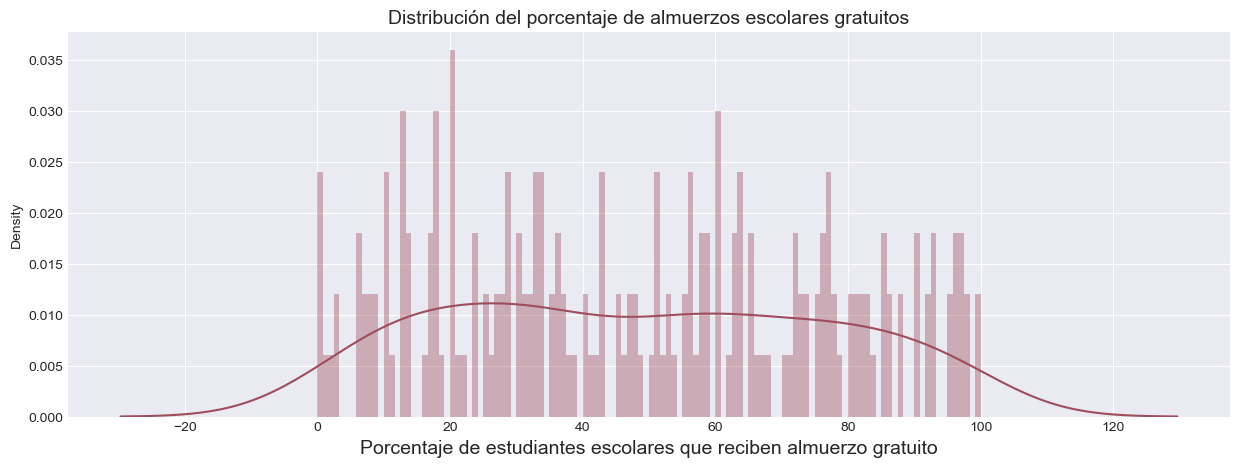

In [74]:
# extract School Types 
plt.figure(figsize=(15,5))
sns.distplot(schools_df['School Percentage Free Lunch'].dropna(), bins=120, color="#9e4d5c")
plt.xlabel('Porcentaje de estudiantes escolares que reciben almuerzo gratuito', fontsize=14);
plt.title("Distribución del porcentaje de almuerzos escolares gratuitos", fontsize=14);
plt.show();

5.4 ¿Qué tipos de escuelas están registradas en su mayoría?

In [75]:
words = " ".join(schools_df['School Name']).split()
from collections import Counter

school_types = Counter(words).most_common(30)[1:9]
school_types = [list(x) for x in school_types]
labels = [x[0]+" School" for x in school_types]
values = [x[1] for x in school_types]

trace2 = go.Bar(
    x=labels,
    y=values,
    name='Donors to Population',
    marker=dict(color='#ff00bb'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    title = 'School Types Distribution',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

La gran mayoría de las escuelas son escuelas primarias (con aproximadamente 35.000 alumnos), una cifra mucho mayor que la de las escuelas secundarias (alrededor de 12.000 alumnos), las escuelas intermedias (alrededor de 9.000 alumnos) o las academias (alrededor de 4.000 alumnos).

6. Exploración de recursos

In [77]:

resources_df.head(5)

,Project ID,Resource Item Name,Resource Quantity,Resource Unit Price,Resource Vendor Name
0,bdd640fb06671ad11c80317fa3b1799d,"gaiam kids stay-n-play balance ball, grey",44.0,398.73,Lakeshore Learning Materials
1,f143262fdc5c0eed8da0365bf89897b9,apple ipad wi-fi 32gb,8.0,135.61,Amazon Business
2,451b4cf36123fdf77656af7229d4beef,sony mdr zx100 blk headphones,17.0,437.49,Amazon Business
3,0e51f30dc6a7ee39c4b032ccd7c524a5,"gaiam kids stay-n-play balance ball, grey",41.0,137.81,NaN
4,0e51f30dc6a7ee39c4b032ccd7c524a5,"serta lounger, mini, sky blue",10.0,171.39,Amazon Business


Hasta abril de 2018, los docentes de diferentes proyectos habían realizado un total de 7.210.448 solicitudes de recursos.

6.2 Artículos más populares

Vamos a obtener los artículos más populares de los datos de recursos. Los artículos más solicitados son aquellos que aparecieron en un gran número de proyectos. Los artículos solicitados en grandes cantidades representan aquellos que se solicitaron en grandes cantidades.

6.2.1 Artículos más solicitados de todos los tiempos
6.2.2 Artículos solicitados en grandes cantidades

In [79]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# ==========================================
# Recursos más solicitados
# ==========================================

t1 = resources_df["Resource Item Name"].value_counts().head(10)

# ==========================================
# Recursos solicitados en mayor cantidad
# ==========================================

t2 = resources_df.sort_values(
    "Resource Quantity",
    ascending=False
).head(10)

# ==========================================
# Crear figura
# ==========================================

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "Recursos Más Solicitados",
        "Recursos Solicitados en Mayor Cantidad"
    ]
)

# Recursos más solicitados

fig.add_trace(
    go.Bar(
        x=t1.index,
        y=t1.values,
        marker_color="#ff5479"
    ),
    row=1,
    col=1
)

# Recursos en mayor cantidad

fig.add_trace(
    go.Bar(
        x=t2["Resource Item Name"],
        y=t2["Resource Quantity"],
        marker_color="#fc839d"
    ),
    row=1,
    col=2
)

fig.update_layout(
    title="Análisis de Recursos Solicitados",
    template="plotly_white",
    height=500,
    width=1200,
    showlegend=False
)

fig.update_xaxes(tickangle=-45)

iplot(fig)

Como podemos observar, el iPad de Apple (iPad Mini, Wi-Fi, 16 o 32 GB) es el artículo más solicitado de todos los tiempos, con más de 30.000 solicitudes en proyectos. Los docentes están muy interesados ​​en utilizar la tecnología en las aulas. Las excursiones son otro de los artículos más solicitados, con más de 20.000 solicitudes en proyectos, lo que demuestra el interés de los docentes por llevar a los estudiantes a viajes educativos o culturales. Otros artículos populares incluyen mamparas de privacidad, mobiliario comercial y asientos acolchados.

Hay muchos artículos que se solicitan en grandes cantidades en uno o más proyectos. Algunos ejemplos son los bloques de cruce de polietileno, los deslizadores de renovación de q-ball y los deslizadores para sillas.

6.3 Artículos más caros

In [82]:
import plotly.graph_objects as go
from plotly.offline import iplot

# ==========================================
# 15 recursos con mayor precio unitario
# ==========================================

t = (
    resources_df
    .sort_values("Resource Unit Price", ascending=False)
    .head(15)
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=t["Resource Item Name"],
        y=t["Resource Unit Price"],
        marker_color="#69efbc"
    )
)

fig.update_layout(
    title="15 Recursos con Mayor Precio Unitario",
    xaxis_title="Recurso",
    yaxis_title="Precio Unitario ($)",
    template="plotly_white",
    height=550,
    width=1000,
    showlegend=False
)

fig.update_xaxes(
    tickangle=-45
)

iplot(fig)